<a href="https://colab.research.google.com/github/Aldy9814/class_BankChurn/blob/preprocessing/Preprocessing_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
from imblearn.over_sampling import SMOTE

1. MOUNT DRIVE & LOAD DATASET

In [ ]:
drive.mount('/content/drive')

path_input = '/content/drive/MyDrive/Dataset_DSAI/Bank_Churn.csv'
df = pd.read_csv(path_input)

print("Data Berhasil Dimuat")
print(f"Ukuran Awal Dataset: {df.shape}\n")

Mounted at /content/drive
Data Berhasil Dimuat
Ukuran Awal Dataset: (10000, 13)



In [ ]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
#Check Duplicate
df.duplicated().sum()

np.int64(0)

In [ ]:
#Check Missing Value
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


2. CLEANING & FEATURE ENGINEERING

In [ ]:
# Drop (CustomerId, Surname, Geography)
df_clean = df.drop(columns=['CustomerId', 'Surname', 'Geography'])

# Encoding Gender: Male -> 1, Female -> 0
df_clean['Gender'] = df_clean['Gender'].map({'Male': 1, 'Female': 0})

print("Proses Cleaning & Encoding Selesai.")
print("Kolom setelah di-encode:")
print(df_clean.columns.tolist())
print(f"Ukuran Dataset setelah di-encode: {df_clean.shape}\n")
df_clean.head()

Proses Cleaning & Encoding Selesai.
Kolom setelah di-encode:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Ukuran Dataset setelah di-encode: (10000, 10)



,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,39,1,0.00,2,0,0,93826.63,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0


3. SEPARASI & PROSES BALANCING (SMOTE)

In [ ]:
df_clean['Exited'].value_counts()

,count
Exited,
0,7963
1,2037


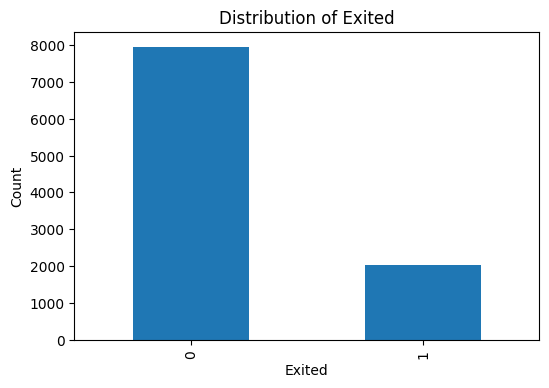

In [ ]:

counts = df_clean['Exited'].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind='bar')

plt.xlabel('Exited')
plt.ylabel('Count')
plt.title('Distribution of Exited')
plt.show()

In [ ]:

X = df_clean.drop(columns=['Exited'])
y = df_clean['Exited']

print("Kondisi Target Terjadinya Churn Sebelum SMOTE:")
print(y.value_counts())

# SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X, y)

df_balanced_smote = pd.DataFrame(X_smote, columns=X.columns)
df_balanced_smote['Exited'] = y_smote

print("\nKondisi Target Terjadinya Churn Setelah SMOTE:")
print(df_balanced_smote['Exited'].value_counts())
print(f"Ukuran Akhir Dataset (SMOTE): {df_balanced_smote.shape}\n")

Kondisi Target Terjadinya Churn Sebelum SMOTE:
Exited
0    7963
1    2037
Name: count, dtype: int64

Kondisi Target Terjadinya Churn Setelah SMOTE:
Exited
1    7963
0    7963
Name: count, dtype: int64
Ukuran Akhir Dataset (SMOTE): (15926, 10)



In [ ]:
df_balanced_smote['Exited'].value_counts()

,count
Exited,
1,7963
0,7963


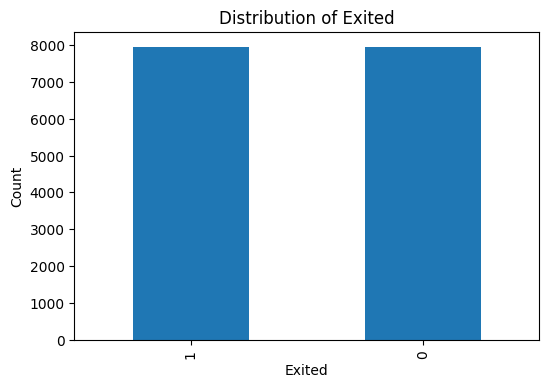

In [ ]:

counts = df_balanced_smote['Exited'].value_counts()

plt.figure(figsize=(6,4))
counts.plot(kind='bar')

plt.xlabel('Exited')
plt.ylabel('Count')
plt.title('Distribution of Exited')

plt.show()

4. MENYIMPAN DATASET HASIL REVISI

In [ ]:

path_output = '/content/drive/MyDrive/Dataset_DSAI/bank_churn_balanced_smote.csv'
df_balanced_smote.to_csv(path_output, index=False)

print(f"File disimpan dengan nama: bank_churn_balanced_smote.csv")

File disimpan dengan nama: bank_churn_balanced_smote.csv
